## Monthly Plots

/home/mayankramchandani/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


✅ Saved summary_table_results.csv with only main predictors


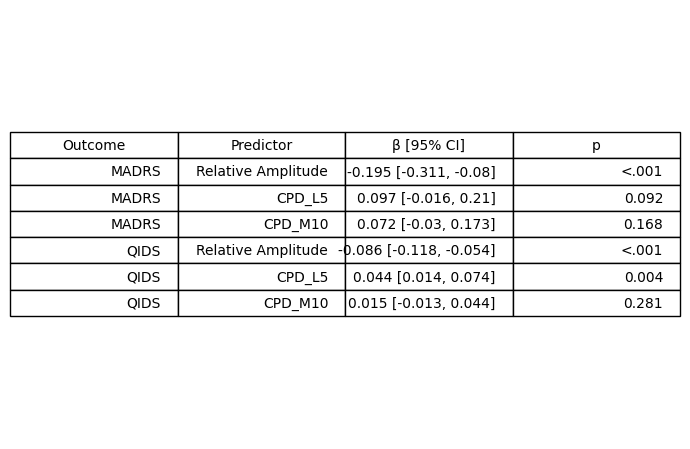

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load all saved model CSVs
madrs_ra = pd.read_csv("madrs_relative_amplitude_results.csv")
madrs_cpd_l5 = pd.read_csv("madrs_cpd_l5_results.csv")
madrs_cpd_m10 = pd.read_csv("madrs_cpd_m10_results.csv")
qids_ra  = pd.read_csv("qids_relative_amplitude_results.csv")
qids_cpd_l5 = pd.read_csv("qids_cpd_l5_results.csv")
qids_cpd_m10 = pd.read_csv("qids_cpd_m10_results.csv")

# Add labels for context
madrs_ra["Outcome"], madrs_ra["Predictor"] = "MADRS", "Relative Amplitude"
madrs_cpd_l5["Outcome"], madrs_cpd_l5["Predictor"] = "MADRS", "CPD_L5"
madrs_cpd_m10["Outcome"], madrs_cpd_m10["Predictor"] = "MADRS", "CPD_M10"
qids_ra["Outcome"], qids_ra["Predictor"] = "QIDS", "Relative Amplitude"
qids_cpd_l5["Outcome"], qids_cpd_l5["Predictor"] = "QIDS", "CPD_L5"
qids_cpd_m10["Outcome"], qids_cpd_m10["Predictor"] = "QIDS", "CPD_M10"

# Combine
all_results = pd.concat([madrs_ra, madrs_cpd_l5, madrs_cpd_m10, qids_ra, qids_cpd_l5, qids_cpd_m10], ignore_index=True)

# --- 🟢 Keep only the main predictor row for each model ---
main_terms = ["relative_amplitude", "CPD_L5", "CPD_M10"]
summary = all_results[all_results["term"].isin(main_terms)].copy()

# --- Keep only the columns needed ---
summary = summary[["Outcome", "Predictor", "beta", "ci_lower", "ci_upper", "p_value"]].copy()

# --- Format for clarity ---
summary["beta"] = summary["beta"].round(3)
summary["ci_lower"] = summary["ci_lower"].round(3)
summary["ci_upper"] = summary["ci_upper"].round(3)
summary["p_value"] = summary["p_value"].apply(lambda x: "<.001" if x < 0.001 else f"{x:.3f}")
summary["β [95% CI]"] = summary.apply(
    lambda r: f"{r['beta']} [{r['ci_lower']}, {r['ci_upper']}]", axis=1
)

# --- Save the minimal summary table ---
summary.to_csv("summary_table_results.csv", index=False)
print("✅ Saved summary_table_results.csv with only main predictors")

# ---- Plot as table ----
fig, ax = plt.subplots(figsize=(7, len(summary)*0.6 + 1))
ax.axis("off")
table = ax.table(
    cellText=summary[["Outcome", "Predictor", "β [95% CI]", "p_value"]].values,
    colLabels=["Outcome", "Predictor", "β [95% CI]", "p"],
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.3)

plt.tight_layout()
plt.savefig("summary_table_results.png", dpi=300, bbox_inches="tight")
plt.show()


In [2]:
readable = {
    'relative_amplitude':'Relative Amplitude',
    'CPD_L5':'Composite Phase Deviation L5',
    'CPD_M10':'Composite Phase Deviation M10',
    'madrs_score':'Total MADRS Score',
    'madrs_lass':'Inactivity/slowness'
}


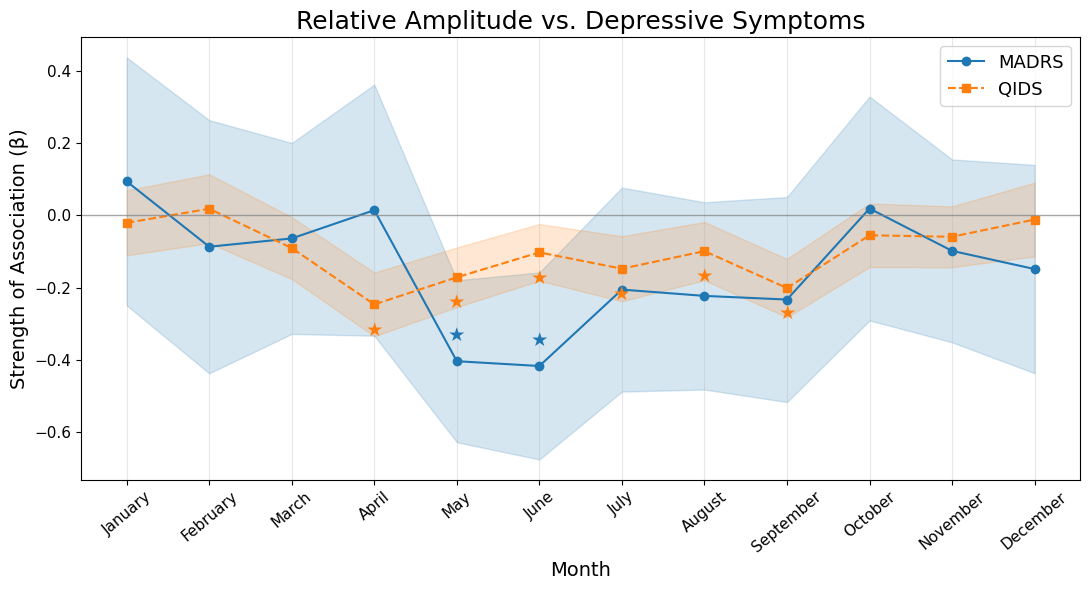

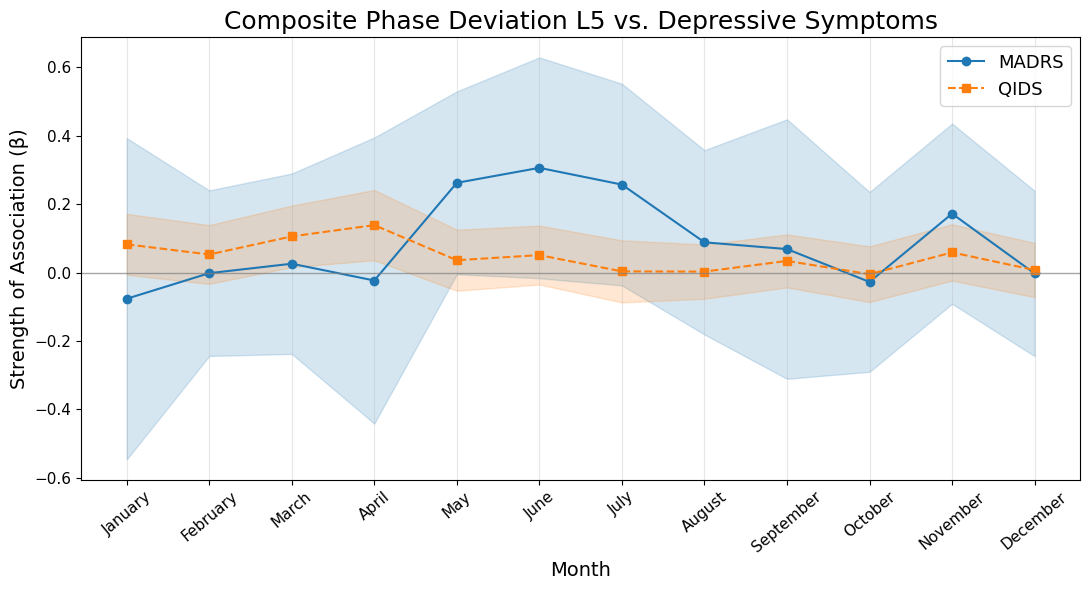

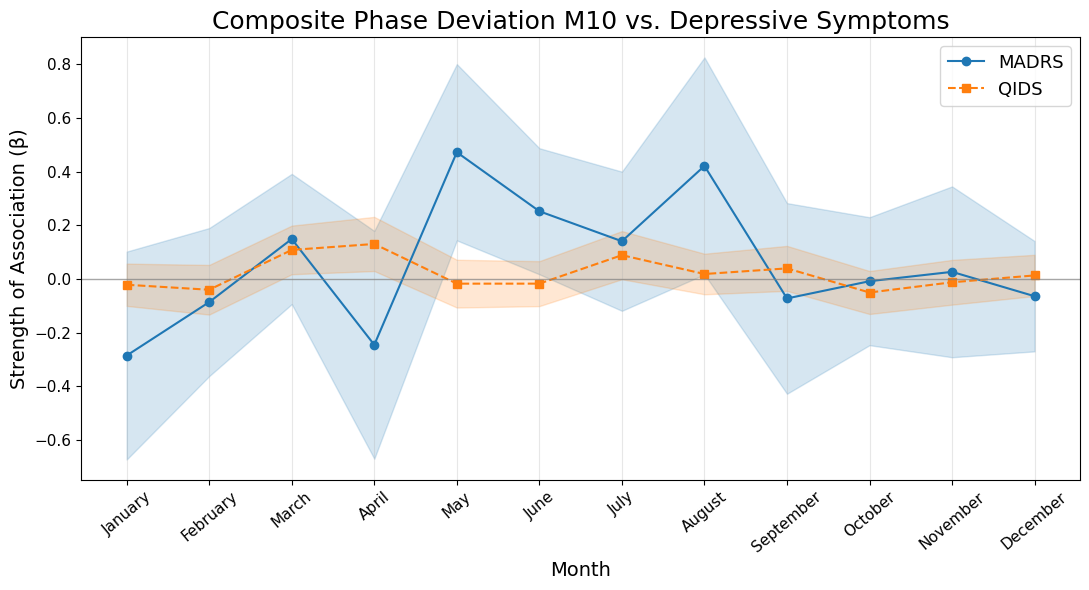

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
from pathlib import Path

# ---------- INPUT FILES ----------
madrs_file = "temp_files/Overall_Monthly_Analysis_Intercepts_MADRS_14_days.csv"
qids_file  = "temp_files/Overall_Monthly_Analysis_Intercepts_QIDS_11_days.csv"

madrs = pd.read_csv(madrs_file)
qids  = pd.read_csv(qids_file)

# ---------- PREP ----------
z = 1.96
for df, outcome in [(madrs, "MADRS"), (qids, "QIDS")]:
    df["ci_lower"] = df["beta_std"] - z * df["se_std"]
    df["ci_upper"] = df["beta_std"] + z * df["se_std"]
    df["outcome"]  = outcome

# Keep only the two energy variables
energy_vars = ["relative_amplitude", "CPD_L5", "CPD_M10"]
readable_energy = {
    "relative_amplitude": "Relative Amplitude",
    "CPD_M10": "Composite Phase Deviation M10",
    "CPD_L5": "Composite Phase Deviation L5"
}

# Month ordering
months = list(range(1, 13))
month_labels = [calendar.month_name[m] for m in months]

Path("temp_files/plots").mkdir(parents=True, exist_ok=True)

# ---------- LOOP OVER RA & CPD ----------
for ev in energy_vars:

    m_ev = madrs[madrs["energy_activity_var"] == ev]
    q_ev = qids[qids["energy_activity_var"] == ev]

    # Reindex monthly
    m_ev = m_ev.set_index("month").reindex(months)
    q_ev = q_ev.set_index("month").reindex(months)

    # Extract values
    m_beta = m_ev["beta_std"].to_numpy(float)
    m_lo   = m_ev["ci_lower"].to_numpy(float)
    m_hi   = m_ev["ci_upper"].to_numpy(float)
    m_pbh  = m_ev["p_value_bh"].to_numpy(float)

    q_beta = q_ev["beta_std"].to_numpy(float)
    q_lo   = q_ev["ci_lower"].to_numpy(float)
    q_hi   = q_ev["ci_upper"].to_numpy(float)
    q_pbh  = q_ev["p_value_bh"].to_numpy(float)

    x = np.arange(len(months))

    plt.figure(figsize=(11, 6))

    # ---------- MADRS (blue) ----------
    plt.plot(x, m_beta, marker="o", label="MADRS", color="#1f77b4")
    plt.fill_between(x, m_lo, m_hi, alpha=0.18, color="#1f77b4")

    # ---------- QIDS (orange) ----------
    plt.plot(x, q_beta, marker="s", linestyle="--", label="QIDS", color="#ff7f0e")
    plt.fill_between(x, q_lo, q_hi, alpha=0.18, color="#ff7f0e")

    # ---------- Add significance stars ----------
    yrng = np.nanmax([m_hi.max(), q_hi.max()]) - np.nanmin([m_lo.min(), q_lo.min()])
    offset = 0.04 * yrng

    for i in range(len(x)):
        if np.isfinite(m_beta[i]) and m_pbh[i] < 0.05:
            plt.text(x[i], m_beta[i] + offset, "★", color="#1f77b4",
                     ha="center", va="bottom", fontsize=14)
        if np.isfinite(q_beta[i]) and q_pbh[i] < 0.05:
            plt.text(x[i], q_beta[i] - offset, "★", color="#ff7f0e",
                     ha="center", va="top", fontsize=14)

    # ---------- Formatting ----------
    plt.axhline(0, lw=1, color="gray", alpha=0.7)
    plt.grid(axis='x', alpha=0.3)

    plt.xticks(x, month_labels, rotation=40, fontsize=11)
    plt.yticks(fontsize=11)

    plt.ylabel("Strength of Association (β)", fontsize=14)
    plt.xlabel("Month", fontsize=14)

    plt.title(f"{readable_energy[ev]} vs. Depressive Symptoms", fontsize=18)
    plt.legend(fontsize=13)

    plt.tight_layout()
    plt.savefig(f"temp_files/plots/monthly_{ev}.png", dpi=300)
    plt.show()


## Seasonal Plots

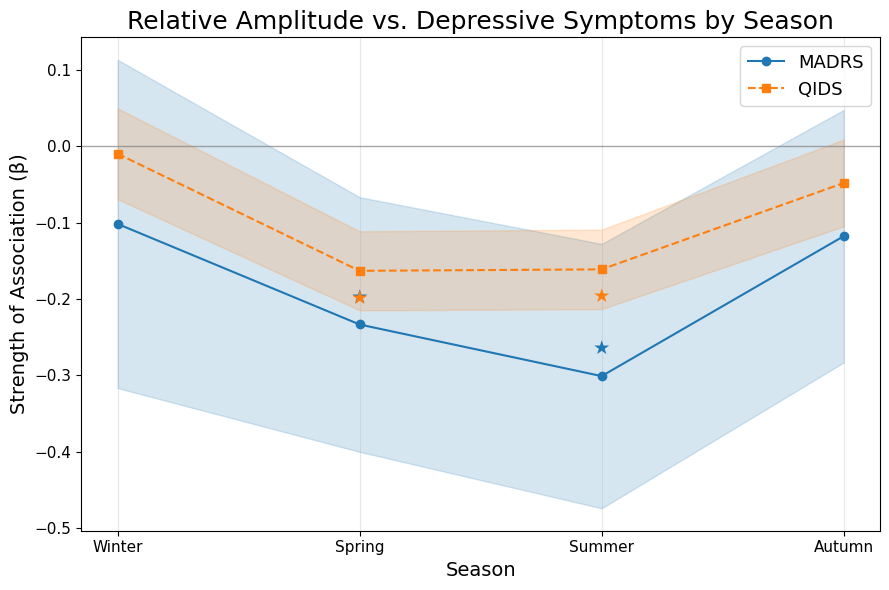

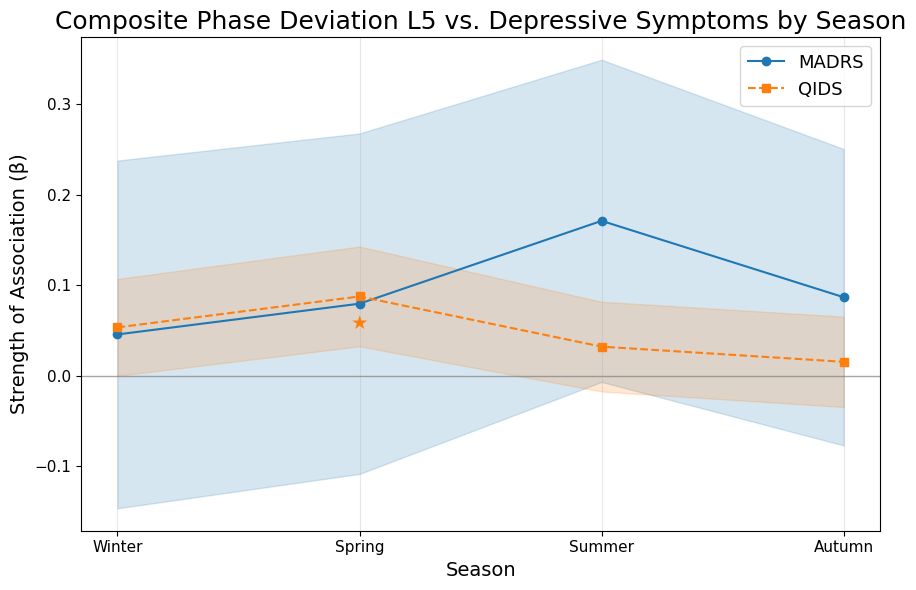

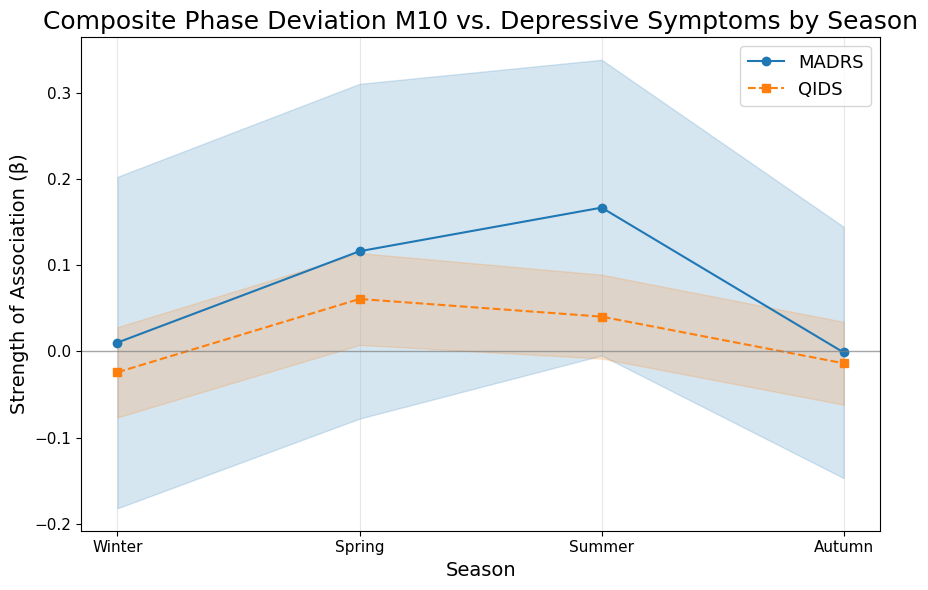

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

madrs_file = "temp_files/Seasonal_Analysis_Intercepts_MADRS_14_days.csv"
qids_file  = "temp_files/Seasonal_Marginal_Effects_QIDS_11_days.csv"
madrs = pd.read_csv(madrs_file)
qids  = pd.read_csv(qids_file)

z = 1.96
for df, outcome in [(madrs, "MADRS"), (qids, "QIDS")]:
    df["ci_lower"] = df["beta_std"] - z * df["se_std"]
    df["ci_upper"] = df["beta_std"] + z * df["se_std"]
    df["outcome"]  = outcome

energy_vars = ["relative_amplitude", "CPD_L5", "CPD_M10"]
readable_energy = {
    "relative_amplitude": "Relative Amplitude",
    "CPD_L5": "Composite Phase Deviation L5",
    "CPD_M10": "Composite Phase Deviation M10"
}

seasons = ["Winter", "Spring", "Summer", "Autumn",]
season_labels = seasons

Path("temp_files/plots").mkdir(parents=True, exist_ok=True)

for ev in energy_vars:
    m_ev = madrs[madrs["energy_activity_var"] == ev].copy()
    q_ev = qids[qids["energy_activity_var"] == ev].copy()

    m_ev["season"] = pd.Categorical(m_ev["season"], categories=seasons, ordered=True)
    q_ev["season"] = pd.Categorical(q_ev["season"], categories=seasons, ordered=True)

    m_ev = m_ev.set_index("season").reindex(seasons)
    q_ev = q_ev.set_index("season").reindex(seasons)

    m_beta = m_ev["beta_std"].to_numpy(dtype=float)
    m_lo   = m_ev["ci_lower"].to_numpy(dtype=float)
    m_hi   = m_ev["ci_upper"].to_numpy(dtype=float)
    m_pbh  = m_ev["p_value_bh"].to_numpy(dtype=float)

    q_beta = q_ev["beta_std"].to_numpy(dtype=float)
    q_lo   = q_ev["ci_lower"].to_numpy(dtype=float)
    q_hi   = q_ev["ci_upper"].to_numpy(dtype=float)
    q_pbh  = q_ev["p_value_bh"].to_numpy(dtype=float)

    x = np.arange(len(seasons))

    plt.figure(figsize=(9, 6))

    plt.plot(x, m_beta, marker="o", label="MADRS", color="#1f77b4")
    plt.fill_between(x, m_lo, m_hi, alpha=0.18, color="#1f77b4")

    plt.plot(x, q_beta, marker="s", linestyle="--", label="QIDS", color="#ff7f0e")
    plt.fill_between(x, q_lo, q_hi, alpha=0.18, color="#ff7f0e")

    yrng = np.nanmax([np.nanmax(m_hi), np.nanmax(q_hi)]) - np.nanmin([np.nanmin(m_lo), np.nanmin(q_lo)])
    offset = 0.04 * yrng

    for i in range(len(x)):
        if np.isfinite(m_beta[i]) and m_pbh[i] < 0.05:
            plt.text(x[i], m_beta[i] + offset, "★", color="#1f77b4",
                     ha="center", va="bottom", fontsize=14)
        if np.isfinite(q_beta[i]) and q_pbh[i] < 0.05:
            plt.text(x[i], q_beta[i] - offset, "★", color="#ff7f0e",
                     ha="center", va="top", fontsize=14)

    plt.axhline(0, lw=1, color="gray", alpha=0.7)
    plt.grid(axis="x", alpha=0.3)

    plt.xticks(x, season_labels, rotation=0, fontsize=11)
    plt.yticks(fontsize=11)

    plt.ylabel("Strength of Association (β)", fontsize=14)
    plt.xlabel("Season", fontsize=14)

    plt.title(f"{readable_energy[ev]} vs. Depressive Symptoms by Season", fontsize=18)
    plt.legend(fontsize=13)

    plt.tight_layout()
    plt.savefig(f"temp_files/plots/seasonal_{ev}.png", dpi=300)
    plt.show()


## Daylight and Temperature

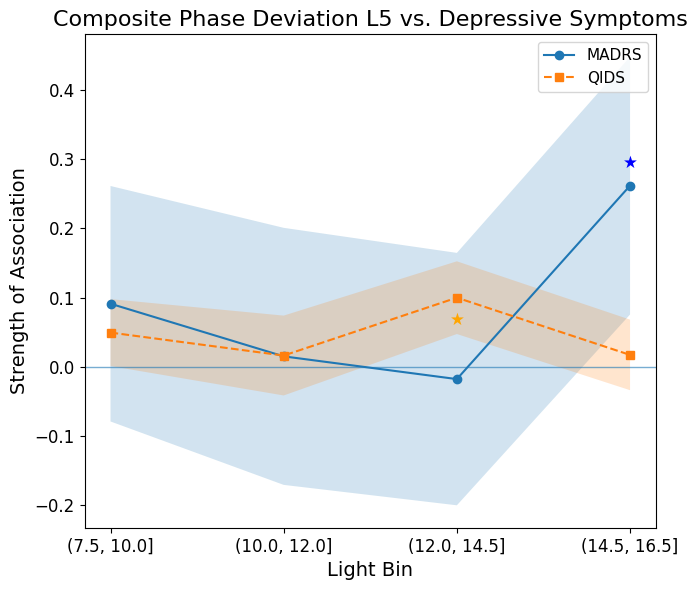

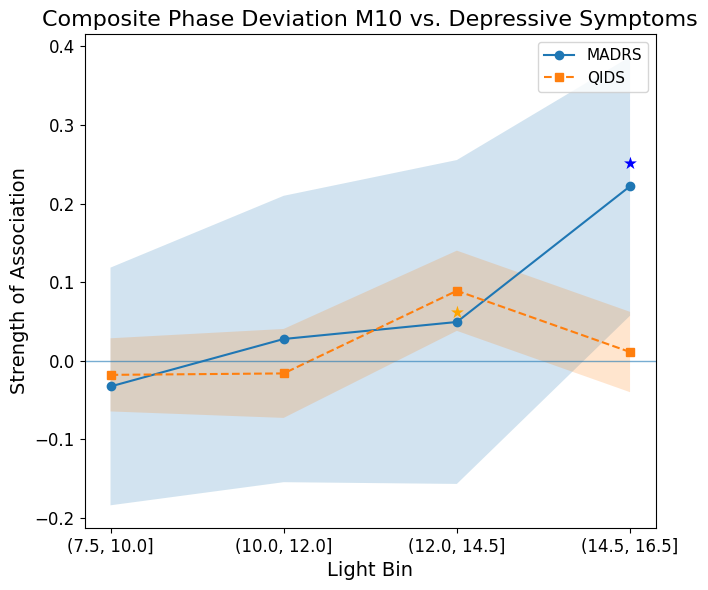

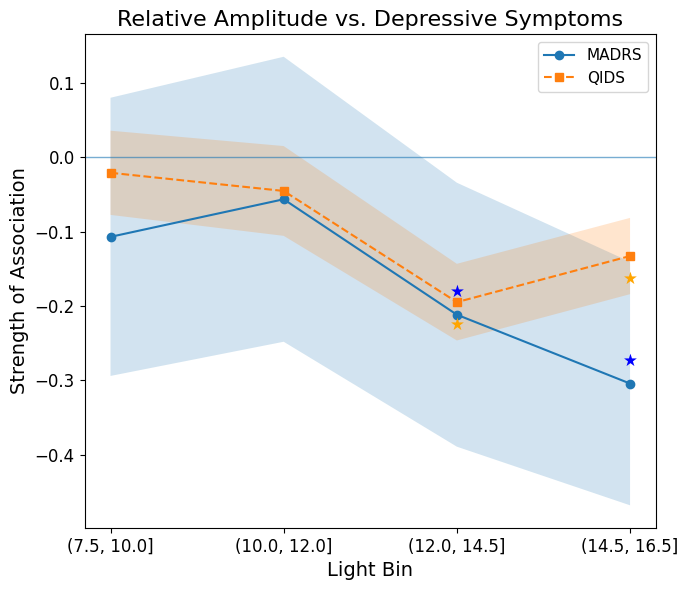

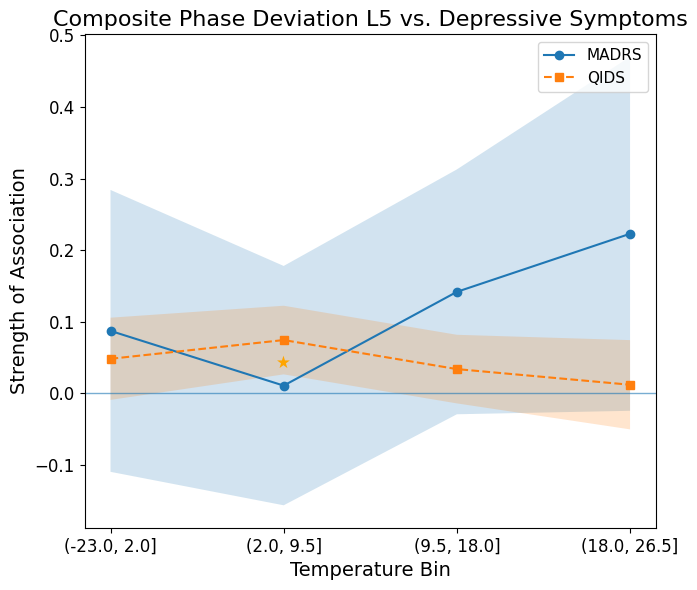

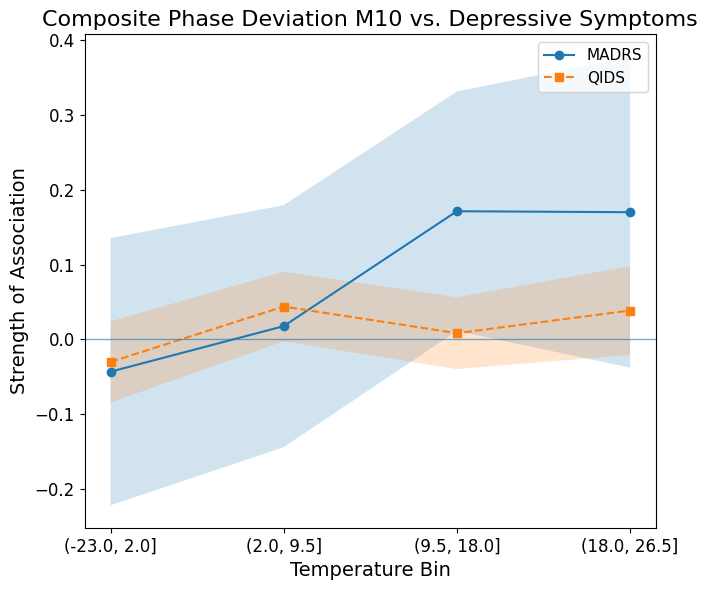

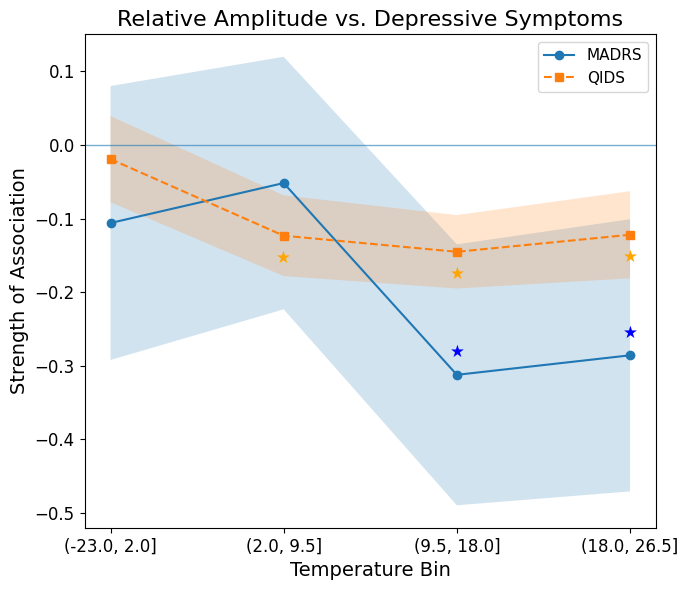

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def _prep(df, outcome_col, bin_col):
    df = df.copy()
    z = 1.96
    df["ci_lower"] = df["beta_std"] - z*df["se_std"]
    df["ci_upper"] = df["beta_std"] + z*df["se_std"]
    df["outcome"]  = df[outcome_col]
    df[bin_col]    = df[bin_col].astype(str)
    return df

def _ordered_bins(dm_ev, dq_ev, bin_col):
    order = list(dict.fromkeys(list(dm_ev[bin_col].dropna()) + list(dq_ev[bin_col].dropna())))
    def try_key(x):
        try:
            return float(x)
        except:
            import re
            nums = re.findall(r"[-+]?\d*\.?\d+", x)
            return float(nums[0]) if nums else np.inf
    if all(s.replace('.','',1).replace('-','',1).isdigit() for s in order):
        order = sorted(order, key=lambda x: float(x))
    else:
        k = [try_key(x) for x in order]
        if any(np.isfinite(k)):
            order = [v for _,v in sorted(zip(k,order), key=lambda t: t[0])]
    return order

def plot_binned(madrs_csv, qids_csv, bin_col, title_bin_label, out_prefix):
    dm = _prep(pd.read_csv(madrs_csv), "madrs_var", bin_col)
    dq = _prep(pd.read_csv(qids_csv),  "qids_var",  bin_col)

    energy_vars = sorted(set(dm["energy_activity_var"]).intersection(dq["energy_activity_var"]))
    readable_energy = {"relative_amplitude": "Relative Amplitude", "CPD_L5": "Composite Phase Deviation L5", "CPD_M10": "Composite Phase Deviation M10"}
    readable_outcome = {"madrs_score": "MADRS", "qidsrtot": "QIDS"}

    Path("temp_files/plots").mkdir(parents=True, exist_ok=True)

    for ev in energy_vars:
        dm_ev = dm[dm["energy_activity_var"]==ev][[bin_col,"beta_std","ci_lower","ci_upper","outcome","p_value_bh"]]
        dq_ev = dq[dq["energy_activity_var"]==ev][[bin_col,"beta_std","ci_lower","ci_upper","outcome","p_value_bh"]]

        bins_all = _ordered_bins(dm_ev, dq_ev, bin_col)
        x = np.arange(len(bins_all))

        dm_ev = dm_ev.set_index(bin_col).reindex(bins_all)
        dq_ev = dq_ev.set_index(bin_col).reindex(bins_all)

        m_beta = dm_ev["beta_std"].to_numpy(dtype=float)
        m_lo   = dm_ev["ci_lower"].to_numpy(dtype=float)
        m_hi   = dm_ev["ci_upper"].to_numpy(dtype=float)
        m_pbh  = dm_ev["p_value_bh"].to_numpy(dtype=float)

        q_beta = dq_ev["beta_std"].to_numpy(dtype=float)
        q_lo   = dq_ev["ci_lower"].to_numpy(dtype=float)
        q_hi   = dq_ev["ci_upper"].to_numpy(dtype=float)
        q_pbh  = dq_ev["p_value_bh"].to_numpy(dtype=float)

        m_lab = readable_outcome.get(dm_ev["outcome"].dropna().iloc[0] if dm_ev["outcome"].notna().any() else "MADRS", "MADRS")
        q_lab = readable_outcome.get(dq_ev["outcome"].dropna().iloc[0] if dq_ev["outcome"].notna().any() else "QIDS",  "QIDS")

        plt.figure(figsize=(7,6))
        plt.plot(x, m_beta, marker="o", label=f"{m_lab}")
        plt.fill_between(x, m_lo, m_hi, alpha=0.2)

        plt.plot(x, q_beta, marker="s", linestyle="--", label=f"{q_lab}")
        plt.fill_between(x, q_lo, q_hi, alpha=0.2)

        y_all = np.concatenate([m_lo, m_hi, q_lo, q_hi])
        y_all = y_all[np.isfinite(y_all)]
        yrng = (np.nanmax(y_all) - np.nanmin(y_all)) if y_all.size else 1.0
        offset = 0.03 * yrng

        for i in range(len(x)):
            if np.isfinite(m_beta[i]) and np.isfinite(m_pbh[i]) and m_pbh[i] < 0.05:
                plt.text(x[i], m_beta[i] + offset, "★", color="blue", ha="center", va="bottom", fontsize=12)
            if np.isfinite(q_beta[i]) and np.isfinite(q_pbh[i]) and q_pbh[i] < 0.05:
                plt.text(x[i], q_beta[i] - offset, "★", color="orange", ha="center", va="top", fontsize=12)

        plt.axhline(0, lw=1, alpha=0.6)
        plt.xticks(x, bins_all, rotation=0)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.xlabel(title_bin_label, fontsize=14)
        plt.ylabel("Strength of Association", fontsize=14)
        plt.title(f"{readable_energy.get(ev, ev)} vs. Depressive Symptoms", fontsize=16)
        plt.legend(
        loc="upper right",
        fontsize=11
        )
        plt.tight_layout()
        plt.savefig(f"temp_files/plots/{out_prefix}_{ev}.png", dpi=300)
        plt.show()

plot_binned(
    madrs_csv="temp_files/Marginal_Effects_light_bin_MADRS_14_days.csv",
    qids_csv ="temp_files/Marginal_Effects_light_bin_QIDS_11_days.csv",
    bin_col="light_bin",
    title_bin_label="Light Bin",
    out_prefix="beta_lines_light"
)

plot_binned(
    madrs_csv="temp_files/Marginal_Effects_temp_bin_MADRS_14_days.csv",
    qids_csv ="temp_files/Marginal_Effects_temp_bin_QIDS_11_days.csv",
    bin_col="temp_bin",
    title_bin_label="Temperature Bin",
    out_prefix="beta_lines_temp"
)


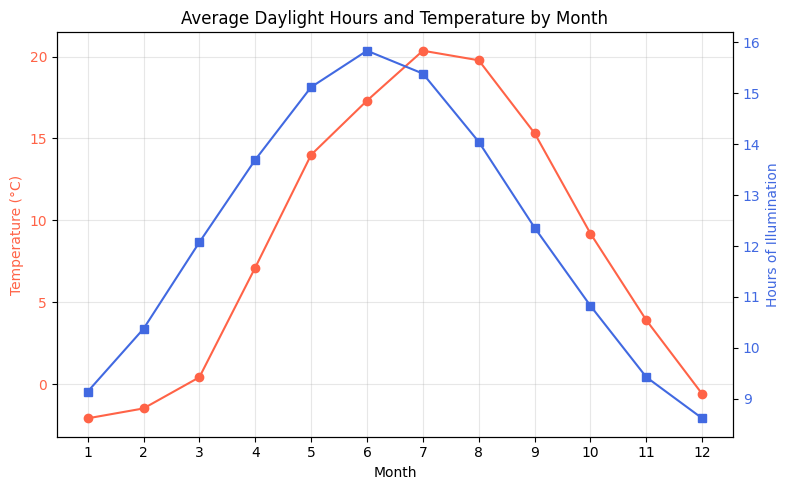

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your file
path = "/home/mayankramchandani/Actigraphy/WELLNESS/temp_files/merged_actigraphy_madrs_temp_light_summary.csv"
#path = "/home/mayankramchandani/Actigraphy/WELLNESS/temp_files/Actigraphy_Part5_Light_Temperature.csv"
df = pd.read_csv(path)

# Rename columns for convenience
df = df.rename(columns={
    "Hours_of_illumination": "Light_Hours",
    "MEAN_TEMPERATURE": "Temperature",
    "avg_Hours_of_illumination": "Avg_Light_Hours",
    "avg_MEAN_TEMPERATURE": "Avg_Temperature"
})

# Select the right columns (prefers averaged if available)
if "Avg_Temperature" in df.columns:
    df["Temperature"] = df["Avg_Temperature"]
if "Avg_Light_Hours" in df.columns:
    df["Light_Hours"] = df["Avg_Light_Hours"]

# Extract month info (if missing)
if "month" not in df.columns:
    if "madrs_date" in df.columns:
        df["madrs_date"] = pd.to_datetime(df["madrs_date"], errors="coerce")
        df["month"] = df["madrs_date"].dt.month
    else:
        print("No date column found; cannot extract month.")
        df["month"] = None

# Compute monthly averages
monthly_summary = (
    df.groupby("month")[["Temperature", "Light_Hours"]]
      .mean()
      .reset_index()
      .sort_values("month")
)

# Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(monthly_summary["month"], monthly_summary["Temperature"], marker="o", color="tomato", label="Mean Temperature (°C)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Temperature (°C)", color="tomato")
ax1.tick_params(axis="y", labelcolor="tomato")

ax2 = ax1.twinx()
ax2.plot(monthly_summary["month"], monthly_summary["Light_Hours"], marker="s", color="royalblue", label="Daylight Hours")
ax2.set_ylabel("Hours of Illumination", color="royalblue")
ax2.tick_params(axis="y", labelcolor="royalblue")

plt.title("Average Daylight Hours and Temperature by Month")
plt.xticks(range(1,13)); ax1.grid(alpha=0.3); plt.tight_layout()
fig.tight_layout()
plt.show()


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# === Load data ===
path = "/home/mayankramchandani/Actigraphy/WELLNESS/temp_files/Actigraphy_Part5_Light_Temperature.csv"
df = pd.read_csv(path)

# Clean + rename
df = df.rename(columns={
    "Hours of illumination (day)": "Light_Hours",
    "MEAN_TEMPERATURE": "Temperature"
})
df["month"] = pd.to_numeric(df["month"], errors="coerce")

# Compute monthly means
monthly = (
    df.groupby("month")[["Temperature", "Light_Hours"]]
      .mean()
      .sort_index()
)
monthly = monthly.reindex(range(1, 13))

# --- Absolute change with January using December as reference ---
def abs_change_with_wrap(s):
    s = s.astype(float)
    diff = s.diff().abs()
    if pd.notna(s.loc[1]) and pd.notna(s.loc[12]):
        diff.loc[1] = abs(s.loc[1] - s.loc[12])
    return diff

roc = pd.DataFrame({
    "AbsDelta_Temperature": abs_change_with_wrap(monthly["Temperature"]),
    "AbsDelta_Light_Hours": abs_change_with_wrap(monthly["Light_Hours"]),
})
roc["month"] = roc.index

# --- Dual-axis line plot (both solid lines) ---
fig, ax1 = plt.subplots(figsize=(9,5))

# Temperature (left y-axis)
ax1.plot(roc["month"], roc["AbsDelta_Temperature"], color="tomato", marker="o", linewidth=2, label="|Δ Temperature| (°C)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Absolute Δ Temperature (°C)", color="tomato")
ax1.tick_params(axis="y", labelcolor="tomato")

# Light (right y-axis)
ax2 = ax1.twinx()
ax2.plot(roc["month"], roc["AbsDelta_Light_Hours"], color="royalblue", marker="s", linewidth=2, label="|Δ Light Hours|")
ax2.set_ylabel("Absolute Δ Light Hours", color="royalblue")
ax2.tick_params(axis="y", labelcolor="royalblue")

# Combined title and formatting
plt.title("Month-to-Month Change Magnitude (January Uses December as Reference)")
plt.xticks(range(1,13))
ax1.grid(alpha=0.3)
plt.tight_layout()

# Create folder and save
os.makedirs("plots_env", exist_ok=True)
plt.savefig("plots_env/abs_change_temp_light_dualaxis.png", dpi=300, bbox_inches="tight")
plt.close()

# --- Save numeric results ---
roc.to_csv("plots_env/abs_change_temp_light_dualaxis_table.csv", index=False)
print("Saved dual-axis solid line plot and table in plots_env/")


Saved dual-axis solid line plot and table in plots_env/


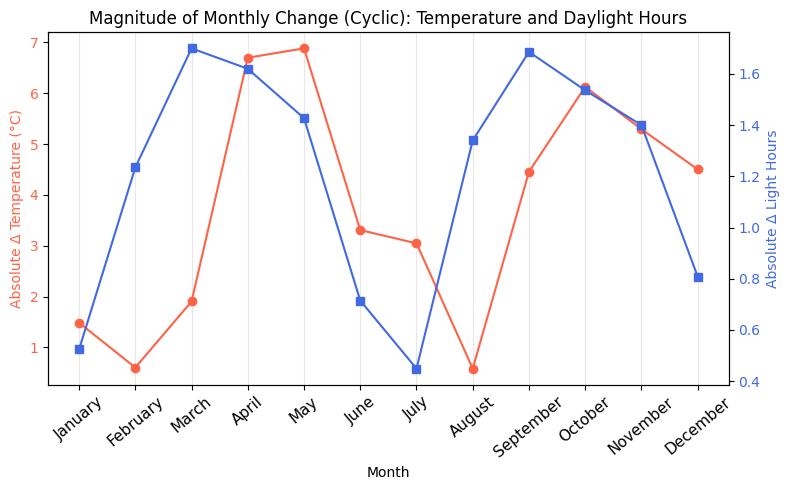

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load and clean ===
path = "/home/mayankramchandani/Actigraphy/WELLNESS/temp_files/merged_actigraphy_madrs_temp_light_summary.csv"
df = pd.read_csv(path)

# Rename for consistency
df = df.rename(columns={
    "Hours_of_illumination": "Light_Hours",
    "MEAN_TEMPERATURE": "Temperature",
    "avg_Hours_of_illumination": "Avg_Light_Hours",
    "avg_MEAN_TEMPERATURE": "Avg_Temperature"
})

# Prefer averaged columns if they exist
if "Avg_Temperature" in df.columns:
    df["Temperature"] = df["Avg_Temperature"]
if "Avg_Light_Hours" in df.columns:
    df["Light_Hours"] = df["Avg_Light_Hours"]

# Derive month
if "month" not in df.columns and "madrs_date" in df.columns:
    df["madrs_date"] = pd.to_datetime(df["madrs_date"], errors="coerce")
    df["month"] = df["madrs_date"].dt.month

# Drop missing months
df = df.dropna(subset=["month"])
df["month"] = df["month"].astype(int)

# Month ordering
months = list(range(1, 13))
month_labels = [calendar.month_name[m] for m in months]

# === Compute monthly averages ===
monthly = (
    df.groupby("month")[["Temperature", "Light_Hours"]]
      .mean()
      .sort_index()
)

# === Compute cyclic month-to-month absolute change ===
rate_change = monthly.copy()
rate_change["Temperature"] = (monthly["Temperature"] - monthly["Temperature"].shift(1, fill_value=monthly["Temperature"].iloc[-1])).abs()
rate_change["Light_Hours"] = (monthly["Light_Hours"] - monthly["Light_Hours"].shift(1, fill_value=monthly["Light_Hours"].iloc[-1])).abs()
rate_change["month"] = rate_change.index

# === Plot ===
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(rate_change["month"], rate_change["Temperature"], marker="o", color="tomato", label="|Δ Temperature| (°C/month)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Absolute Δ Temperature (°C)", color="tomato")
ax1.tick_params(axis="y", labelcolor="tomato")

ax2 = ax1.twinx()
ax2.plot(rate_change["month"], rate_change["Light_Hours"], marker="s", color="royalblue", label="|Δ Daylight Hours|/month")
ax2.set_ylabel("Absolute Δ Light Hours", color="royalblue")
ax2.tick_params(axis="y", labelcolor="royalblue")

plt.title("Magnitude of Monthly Change (Cyclic): Temperature and Daylight Hours")
ax1.grid(axis='x', alpha=0.3)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(month_labels, rotation=40, fontsize=11)
fig.tight_layout()
plt.show()


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

path = "/home/mayankramchandani/Actigraphy/WELLNESS/temp_files/merged_actigraphy_madrs_temp_light_summary.csv"
df = pd.read_csv(path)

df = df.rename(columns={
    "Hours_of_illumination": "Light_Hours",
    "MEAN_TEMPERATURE": "Temperature",
    "avg_Hours_of_illumination": "Avg_Light_Hours",
    "avg_MEAN_TEMPERATURE": "Avg_Temperature"
})
if "Avg_Temperature" in df.columns: df["Temperature"] = df["Avg_Temperature"]
if "Avg_Light_Hours" in df.columns: df["Light_Hours"] = df["Avg_Light_Hours"]

if "month" not in df.columns and "madrs_date" in df.columns:
    df["madrs_date"] = pd.to_datetime(df["madrs_date"], errors="coerce")
    df["month"] = df["madrs_date"].dt.month
df = df.dropna(subset=["month"]).copy()
df["month"] = df["month"].astype(int)

monthly = (
    df.groupby("month")[["Temperature", "Light_Hours"]]
      .mean()
      .sort_index()
).reindex(range(1, 13))

def cyclic_diff(s):
    s = s.astype(float)
    d = s.diff()
    if pd.notna(s.loc[1]) and pd.notna(s.loc[12]):
        d.loc[1] = s.loc[1] - s.loc[12]
    return d

signed = pd.DataFrame({
    "ΔTemperature": cyclic_diff(monthly["Temperature"]),
    "ΔLight": cyclic_diff(monthly["Light_Hours"]),
})
signed["month"] = signed.index

mag = signed.copy()
mag["ΔTemperature"] = mag["ΔTemperature"].abs()
mag["ΔLight"] = mag["ΔLight"].abs()

os.makedirs("plots_env", exist_ok=True)
signed.to_csv("plots_env/monthly_change_signed.csv", index=False)
mag.to_csv("plots_env/monthly_change_abs.csv", index=False)

# Signed change plot (dual axes, solid lines)
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(signed["month"], signed["ΔTemperature"], color="tomato", marker="o", linewidth=2, label="Δ Temperature (°C)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Δ Temperature (°C)", color="tomato"); ax1.tick_params(axis="y", labelcolor="tomato")

ax2 = ax1.twinx()
ax2.plot(signed["month"], signed["ΔLight"], color="royalblue", marker="s", linewidth=2, label="Δ Light Hours")
ax2.set_ylabel("Δ Light Hours", color="royalblue"); ax2.tick_params(axis="y", labelcolor="royalblue")

plt.title("Month-to-Month Change (Signed): Temperature & Light (Jan vs Dec)")
plt.xticks(range(1,13)); ax1.grid(alpha=0.3); plt.tight_layout()
plt.savefig("plots_env/monthly_change_signed_dualaxis.png", dpi=300, bbox_inches="tight")
plt.close()

# Magnitude-only plot (dual axes, solid lines)
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(mag["month"], mag["ΔTemperature"], color="tomato", marker="o", linewidth=2, label="|Δ Temperature| (°C)")
ax1.set_xlabel("Month")
ax1.set_ylabel("|Δ Temperature| (°C)", color="tomato"); ax1.tick_params(axis="y", labelcolor="tomato")

ax2 = ax1.twinx()
ax2.plot(mag["month"], mag["ΔLight"], color="royalblue", marker="s", linewidth=2, label="|Δ Light Hours|")
ax2.set_ylabel("|Δ Light Hours|", color="royalblue"); ax2.tick_params(axis="y", labelcolor="royalblue")

plt.title("Month-to-Month Change (Magnitude): Temperature & Light (Jan vs Dec)")
plt.xticks(range(1,13)); ax1.grid(alpha=0.3); plt.tight_layout()
plt.savefig("plots_env/monthly_change_abs_dualaxis.png", dpi=300, bbox_inches="tight")
plt.close()


In [10]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

path = "merged_actigraphy_madrs_temp_light_summary.csv"
df = pd.read_csv(path)

df = df.rename(columns={
    "Hours_of_illumination": "Light_Hours",
    "MEAN_TEMPERATURE": "Temperature",
    "avg_Hours_of_illumination": "Avg_Light_Hours",
    "avg_MEAN_TEMPERATURE": "Avg_Temperature"
})
if "Avg_Temperature" in df.columns:
    df["Temperature"] = df["Avg_Temperature"]
if "Avg_Light_Hours" in df.columns:
    df["Light_Hours"] = df["Avg_Light_Hours"]

df["madrs_date"] = pd.to_datetime(df["madrs_date"], errors="coerce")
df["month"] = df["madrs_date"].dt.month

meta_path = "/home/mayankramchandani/Actigraphy/WELLNESS/data/output_raw gt3x files/wellness20200527.xlsx"
df_meta = pd.read_excel(meta_path)
meta_subset = df_meta[["subjID", "age", "sex", "MADRS.BL"]].copy()
meta_subset.columns = ["madrs_id", "age", "sex", "madrs_baseline"]

df["madrs_id"] = df["madrs_id"].astype(str).str.strip()
meta_subset["madrs_id"] = meta_subset["madrs_id"].astype(str).str.strip()

df = df.merge(meta_subset, on="madrs_id", how="left")

monthly = (
    df.groupby(["site", "month"])[["Temperature", "Light_Hours"]]
      .mean()
      .reset_index()
)

monthly = monthly.sort_values(["site", "month"])
monthly["ΔTemperature"] = monthly.groupby("site")["Temperature"].diff()
monthly["ΔLight_Hours"] = monthly.groupby("site")["Light_Hours"].diff()

monthly["ΔTemperature"] = monthly["ΔTemperature"].abs()
monthly["ΔLight_Hours"] = monthly["ΔLight_Hours"].abs()

df = df.merge(
    monthly[["site", "month", "ΔTemperature", "ΔLight_Hours"]],
    on=["site", "month"],
    how="left"
)

energy_vars = ["relative_amplitude", "CPD_L5", "CPD_M10"]

scaler = StandardScaler()
for col in ["Temperature", "Light_Hours", "ΔTemperature", "ΔLight_Hours", "age"] + energy_vars:
    if col in df.columns:
        df[col] = scaler.fit_transform(df[[col]])

df["sex"] = df["sex"].astype("category")

results = {}

for var in energy_vars:
    needed = [
        "madrs_score",
        var,
        "ΔLight_Hours",
        "ΔTemperature",
        "age",
        "sex",
        "madrs_baseline",
        "madrs_id",
    ]

    madrs_data = (
        df.dropna(subset=needed)
          .reset_index(drop=True)
    )

    formula_light = f"madrs_score ~ {var} * ΔLight_Hours + age + C(sex) + madrs_baseline"
    model_light = smf.mixedlm(
        formula_light,
        groups=madrs_data["madrs_id"],
        re_formula="1",
        data=madrs_data
    ).fit()
    print(f"\n=== LME for {var} with ΔLight moderation only ===")
    print(model_light.summary())

    formula_temp = f"madrs_score ~ {var} * ΔTemperature + age + C(sex) + madrs_baseline"
    model_temp = smf.mixedlm(
        formula_temp,
        groups=madrs_data["madrs_id"],
        re_formula="1",
        data=madrs_data
    ).fit()
    print(f"\n=== LME for {var} with ΔTemperature moderation only ===")
    print(model_temp.summary())

    results[(var, "ΔLight_Hours")] = model_light
    results[(var, "ΔTemperature")] = model_temp


=== LME for relative_amplitude with ΔLight moderation only ===
                  Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      madrs_score
No. Observations:        700          Method:                  REML       
No. Groups:              92           Scale:                   37.6464    
Min. group size:         1            Log-Likelihood:          -2322.4317 
Max. group size:         16           Converged:               Yes        
Mean group size:         7.6                                              
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        4.826    0.859  5.620 0.000  3.143  6.509
C(sex)[T.2.0]                   -0.891    1.049 -0.849 0.396 -2.948  1.166
relative_amplitude              -1.625    0.311 -5.227 

KeyError: ['CPD_L5']

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Store results
beta_light = {}
beta_temp = {}
ci_light = {}
ci_temp = {}

for var in energy_vars:
    # Fit ΔLight-only model
    formula_light = f"madrs_score ~ {var} * ΔLight_Hours + age + C(sex) + madrs_baseline"
    mL = smf.mixedlm(formula_light, groups=madrs_data["madrs_id"],
                     re_formula="1", data=madrs_data).fit()
    
    # Fit ΔTemp-only model
    formula_temp = f"madrs_score ~ {var} * ΔTemperature + age + C(sex) + madrs_baseline"
    mT = smf.mixedlm(formula_temp, groups=madrs_data["madrs_id"],
                     re_formula="1", data=madrs_data).fit()

    int_light_name = f"{var}:ΔLight_Hours"
    int_temp_name  = f"{var}:ΔTemperature"

    beta_light[var] = mL.params.get(int_light_name, 0)
    beta_temp[var]  = mT.params.get(int_temp_name, 0)

    seL = mL.bse.get(int_light_name, np.nan)
    seT = mT.bse.get(int_temp_name, np.nan)

    ci_light[var] = (beta_light[var] - 1.96*seL, beta_light[var] + 1.96*seL)
    ci_temp[var]  = (beta_temp[var]  - 1.96*seT, beta_temp[var]  + 1.96*seT)


# -----------------------------
# Plot β for ΔLight interactions
# -----------------------------
labels = [readable[v] for v in energy_vars]
betas = [beta_light[v] for v in energy_vars]
ci_lo = [ci_light[v][0] for v in energy_vars]
ci_hi = [ci_light[v][1] for v in energy_vars]

plt.figure(figsize=(6,5))
plt.errorbar(labels, betas, 
             yerr=[np.array(betas)-np.array(ci_lo), 
                   np.array(ci_hi)-np.array(betas)],
             fmt="o", capsize=5, color="royalblue")
plt.axhline(0, color="gray")
plt.ylabel("Standardized β (interaction)")
plt.title("ΔLight moderation: Standardized β for var × ΔLight")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# Plot β for ΔTemperature interactions
# -----------------------------
betas = [beta_temp[v] for v in energy_vars]
ci_lo = [ci_temp[v][0] for v in energy_vars]
ci_hi = [ci_temp[v][1] for v in energy_vars]

plt.figure(figsize=(6,5))
plt.errorbar(labels, betas, 
             yerr=[np.array(betas)-np.array(ci_lo), 
                   np.array(ci_hi)-np.array(betas)],
             fmt="o", capsize=5, color="tomato")
plt.axhline(0, color="gray")
plt.ylabel("Standardized β (interaction)")
plt.title("ΔTemperature moderation: Standardized β for var × ΔTemperature")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


KeyError: 'CPD'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------------------
# 1) Load QIDS data and climate columns
# ---------------------------------------------------------------------
qids_path = "temp_files/1_week_avg_actigraphy_part5_qids.csv"
df_q = pd.read_csv(qids_path)

# Rename climate columns for consistency
df_q = df_q.rename(columns={
    "Hours of illumination (day)": "Light_Hours",
    "MEAN_TEMPERATURE": "Temperature"
})

# QIDS date → month
df_q["qids_date"] = pd.to_datetime(df_q["qids_date"], errors="coerce")
df_q["month"] = df_q["qids_date"].dt.month

# ---------------------------------------------------------------------
# 2) Merge age / sex from meta
# ---------------------------------------------------------------------
meta_path = "/home/mayankramchandani/Actigraphy/WELLNESS/data/output_raw gt3x files/wellness20200527.xlsx"
df_meta = pd.read_excel(meta_path)

meta_subset = df_meta[["subjID", "age", "sex"]].copy()
meta_subset.columns = ["qids_id", "age", "sex"]

df_q["qids_id"] = df_q["qids_id"].astype(str).str.strip()
meta_subset["qids_id"] = meta_subset["qids_id"].astype(str).str.strip()

df_q = df_q.merge(meta_subset, on="qids_id", how="left")

# ---------------------------------------------------------------------
# 3) Compute monthly ΔTemperature / ΔLight_Hours (per site if available)
# ---------------------------------------------------------------------
group_cols = ["month"]
if "site" in df_q.columns:
    group_cols = ["site", "month"]

monthly = (
    df_q.groupby(group_cols)[["Temperature", "Light_Hours"]]
        .mean()
        .reset_index()
        .sort_values(group_cols)
)

# signed diff first
monthly["ΔTemperature"] = monthly.groupby(group_cols[:-1])["Temperature"].diff() if len(group_cols) > 1 else monthly["Temperature"].diff()
monthly["ΔLight_Hours"] = monthly.groupby(group_cols[:-1])["Light_Hours"].diff() if len(group_cols) > 1 else monthly["Light_Hours"].diff()

# use magnitude (absolute change) like in the MADRS script
monthly["ΔTemperature"] = monthly["ΔTemperature"].abs()
monthly["ΔLight_Hours"] = monthly["ΔLight_Hours"].abs()

# merge Δs back
df_q = df_q.merge(
    monthly[group_cols + ["ΔTemperature", "ΔLight_Hours"]],
    on=group_cols,
    how="left"
)

# ---------------------------------------------------------------------
# 4) Standardize predictors and covariates
# ---------------------------------------------------------------------
energy_vars = ["relative_amplitude", "CPD"]

scaler = StandardScaler()
for col in ["Temperature", "Light_Hours", "ΔTemperature", "ΔLight_Hours", "age"] + energy_vars:
    if col in df_q.columns:
        df_q[col] = scaler.fit_transform(df_q[[col]])

df_q["sex"] = df_q["sex"].astype("category")

readable = {
    "relative_amplitude": "Relative Amplitude",
    "CPD": "Composite Phase Deviation"
}

# ---------------------------------------------------------------------
# 5) Fit LME: QIDS ~ RA/CPD with ΔTemp & ΔLight moderation
#    and plot slopes vs Δ variables (signed & magnitude)
# ---------------------------------------------------------------------
for var in energy_vars:
    needed = [
        "qidsrtot",
        var,
        "ΔLight_Hours",
        "ΔTemperature",
        "age",
        "sex",
        "qids_id",
    ]
    qids_data = df_q.dropna(subset=needed).reset_index(drop=True)
    if qids_data.empty:
        print(f"No data for {var}, skipping.")
        continue

    # 1) ΔLight moderation only
    formula_light = (
        f"qidsrtot ~ {var} * ΔLight_Hours + age + C(sex)"
    )

    model_light = smf.mixedlm(
        formula_light,
        groups=qids_data["qids_id"],
        re_formula="1",
        data=qids_data
    ).fit()

    print(f"\n=== QIDS LME for {var} with ΔLight moderation only ===")
    print(model_light.summary())

    # 2) ΔTemperature moderation only
    formula_temp = (
        f"qidsrtot ~ {var} * ΔTemperature + age + C(sex)"
    )

    model_temp = smf.mixedlm(
        formula_temp,
        groups=qids_data["qids_id"],
        re_formula="1",
        data=qids_data
    ).fit()

    print(f"\n=== QIDS LME for {var} with ΔTemperature moderation only ===")
    print(model_temp.summary())


=== QIDS LME for relative_amplitude with ΔLight moderation only ===
                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       qidsrtot  
No. Observations:       2913          Method:                   REML      
No. Groups:             93            Scale:                    8.8855    
Min. group size:        1             Log-Likelihood:           -7470.8225
Max. group size:        85            Converged:                Yes       
Mean group size:        31.3                                              
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        6.640    0.475 13.965 0.000  5.708  7.572
C(sex)[T.2.0]                   -0.005    0.748 -0.006 0.995 -1.470  1.461
relative_amplitude              -0.397    0.075 -5

## Sensitivity Analysis - Months for Relapsers

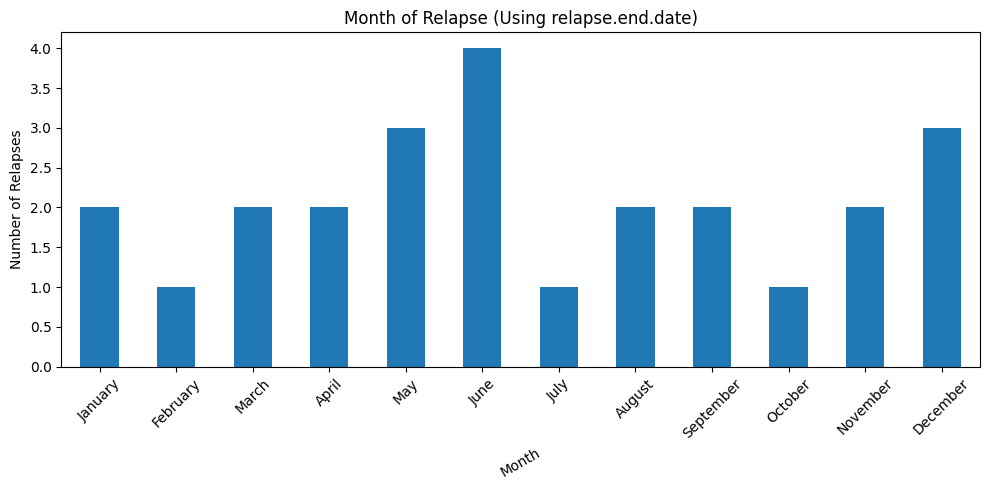

In [ ]:
file = ""

#Relapsers, month of relapse

import pandas as pd
import matplotlib.pyplot as plt

# --- Load your data ---
df = pd.read_excel("/home/mayankramchandani/Actigraphy/WELLNESS/data/output_raw gt3x files/wellness20200527.xlsx")

# --- Ensure date is parsed correctly ---
df["relapse.end.date"] = pd.to_datetime(df["relapse.end.date"], errors="coerce")

# --- Filter only relapsers ---
relapsers = df[df["group"] == "relapse"].copy()

# --- Extract month (name or number) ---
relapsers["relapse_month"] = relapsers["relapse.end.date"].dt.month_name()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

# --- Plot ---
plt.figure(figsize=(10,5))
relapsers["relapse_month"].value_counts().reindex(month_order).plot(
    kind="bar"
)

plt.title("Month of Relapse (Using relapse.end.date)")
plt.xlabel("Month", rotation=30)
plt.ylabel("Number of Relapses")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
import pandas as pd

# Load data
df = pd.read_excel("/home/mayankramchandani/Actigraphy/WELLNESS/data/output_raw gt3x files/wellness20200527.xlsx")

# Parse relapse date
df["relapse.end.date"] = pd.to_datetime(df["relapse.end.date"], errors="coerce")

# Keep only relapsers with valid relapse dates
relapsers = df[(df["group"] == "relapse") & (~df["relapse.end.date"].isna())].copy()

# -----------------------------
# Month counts
# -----------------------------
relapsers["relapse_month"] = relapsers["relapse.end.date"].dt.month_name()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

month_counts = (
    relapsers["relapse_month"]
    .value_counts()
    .reindex(month_order, fill_value=0)
)

# -----------------------------
# Astronomical seasons (no overlap)
# -----------------------------
def assign_astronomical_season(date):
    y = date.year

    # Astronomical boundaries by year
    boundaries = {
        2016: {
            "spring": pd.Timestamp("2016-03-20"),
            "summer": pd.Timestamp("2016-06-20"),
            "autumn": pd.Timestamp("2016-09-22"),
            "winter": pd.Timestamp("2016-12-21"),
        },
        2017: {
            "spring": pd.Timestamp("2017-03-20"),
            "summer": pd.Timestamp("2017-06-21"),
            "autumn": pd.Timestamp("2017-09-22"),
            "winter": pd.Timestamp("2017-12-21"),
        },
        2018: {
            "spring": pd.Timestamp("2018-03-20"),
            "summer": pd.Timestamp("2018-06-21"),
            "autumn": pd.Timestamp("2018-09-22"),
            "winter": pd.Timestamp("2018-12-21"),
        },
        2019: {
            "spring": pd.Timestamp("2019-03-20"),
            "summer": pd.Timestamp("2019-06-21"),
            "autumn": pd.Timestamp("2019-09-23"),
            "winter": pd.Timestamp("2019-12-21"),
        },
    }

    if y not in boundaries:
        return pd.NA

    spring_start = boundaries[y]["spring"]
    summer_start = boundaries[y]["summer"]
    autumn_start = boundaries[y]["autumn"]
    winter_start = boundaries[y]["winter"]

    if spring_start <= date < summer_start:
        return "Spring"
    elif summer_start <= date < autumn_start:
        return "Summer"
    elif autumn_start <= date < winter_start:
        return "Autumn"
    else:
        # Winter includes Jan 1 up to spring start, and winter start to Dec 31
        return "Winter"

relapsers["season"] = relapsers["relapse.end.date"].apply(assign_astronomical_season)

season_order = ["Spring", "Summer", "Autumn", "Winter"]
season_counts = (
    relapsers["season"]
    .value_counts()
    .reindex(season_order, fill_value=0)
)

# -----------------------------
# Print text results
# -----------------------------
print("Relapsers by month:")
for month, count in month_counts.items():
    print(f"{month}: {count}")

print("\nRelapsers by astronomical season:")
for season, count in season_counts.items():
    print(f"{season}: {count}")

print(f"\nTotal number of relapse records: {len(relapsers)}")

# -----------------------------
# Optional: save tables
# -----------------------------
month_table = month_counts.reset_index()
month_table.columns = ["Month", "N_relapsers"]
month_table.to_csv("temp_files/relapsers_by_month.csv", index=False)

season_table = season_counts.reset_index()
season_table.columns = ["Season", "N_relapsers"]
season_table.to_csv("temp_files/relapsers_by_astronomical_season.csv", index=False)

print("\nSaved:")
print(" - temp_files/relapsers_by_month.csv")
print(" - temp_files/relapsers_by_astronomical_season.csv")

Relapsers by month:
January: 2
February: 1
March: 2
April: 2
May: 3
June: 4
July: 1
August: 2
September: 2
October: 1
November: 2
December: 3

Relapsers by astronomical season:
Spring: 7
Summer: 5
Autumn: 7
Winter: 6

Total number of relapse records: 25

Saved:
 - temp_files/relapsers_by_month.csv
 - temp_files/relapsers_by_astronomical_season.csv
